In [43]:
# from pyspark.sql import SparkSession
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# sns.set(style="whitegrid")

# # Stop SparkSession jika ada yang aktif
# try:
#     spark.stop()
# except:
#     pass

# # Buat spark session
# spark = SparkSession.builder \
#     .appName("ChurnPredictionEDA") \
#     .config("spark.driver.memory", "12g") \
#     .config("spark.driver.maxResultSize", "4g") \
#     .getOrCreate()

In [44]:
# master_table_path = "data/master_feature_table.parquet"

# print(f"Memuat data dari {master_table_path}...")
# master_table_spark = spark.read.parquet(master_table_path)
# master_table_spark.cache()

# # print schema
# print("Skema master_table:")
# master_table_spark.printSchema()

# # convert to Pandas DataFrame for visualization
# print("\nMengonversi ke Pandas DataFrame")
# master_table_pd = master_table_spark.toPandas()

# # display data
# display(master_table_pd.head())

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


master_table_path = "data/data_final/master_feature_table_final.parquet"


master_table_pd = pd.read_parquet(master_table_path)
    
# Di Spark: .printSchema() -> Di Pandas: .info()
print("\nSkema master_table:")
print(master_table_pd.info())

# Di Spark: display() -> Di Pandas: print() atau .head()
print("\n5 Baris Pertama:")
print(master_table_pd.head())



Skema master_table:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1082190 entries, 0 to 1082189
Data columns (total 20 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   msno                          1082190 non-null  object 
 1   is_churn                      1082190 non-null  int32  
 2   city                          1082190 non-null  int32  
 3   age_group                     961431 non-null   object 
 4   registered_via                1082190 non-null  int32  
 5   total_transactions            1082190 non-null  int64  
 6   total_plan_days               1082190 non-null  int64  
 7   total_amount_paid             1082190 non-null  float64
 8   avg_amount_paid               1082190 non-null  float64
 9   count_auto_renew              1082190 non-null  int64  
 10  count_cancel                  1082190 non-null  int64  
 11  most_frequent_payment_method  1082190 non-null  int32  
 12  days_si

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import math

# UNKOMENT jika menggunakan Spark
#from pyspark.sql.functions import col
#from pyspark.sql import Window
#import pyspark.sql.functions as F
#from pyspark.ml.stat import Correlation
#from pyspark.ml.feature import VectorAssembler


# EDA USER LOGS

## Menampilkan outliers

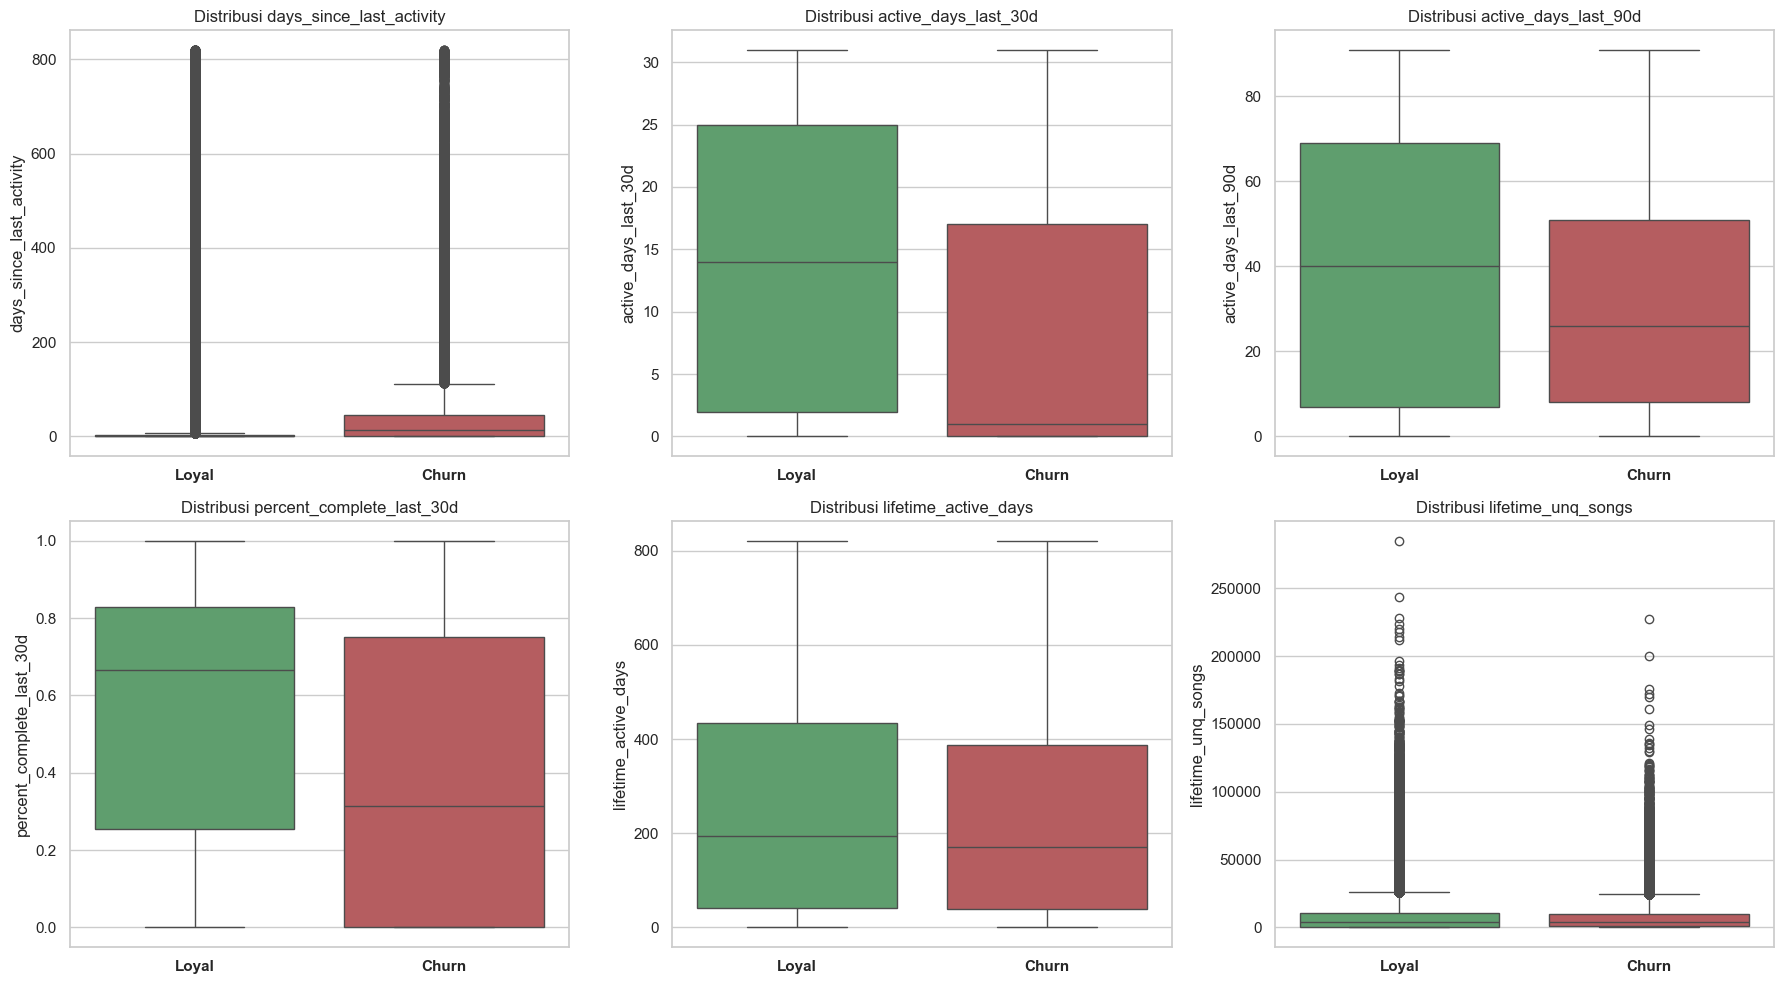

In [ ]:
# Daftar fitur logs
log_features = [
    'days_since_last_activity', 
    'active_days_last_30d', 
    'active_days_last_90d', 
    'percent_complete_last_30d', 
    'lifetime_active_days', 
    'lifetime_unq_songs'
]


# Churn = merah, Loyal = hijau
custom_colors = {
    0: "#55a868", 1: "#c44e52",     
    "0": "#55a868", "1": "#c44e52"  
}


# Setup Grid
n_cols = 3
n_rows = math.ceil(len(log_features) / n_cols)
plt.figure(figsize=(18, 5 * n_rows))

for i, feature in enumerate(log_features):
    plt.subplot(n_rows, n_cols, i + 1)
    
    sns.boxplot(
        data=master_table_pd, 
        x='is_churn', 
        y=feature, 
        hue='is_churn',         
        palette=custom_colors,  
        legend=False            # Matikan legend bawaan
    )


    plt.ticklabel_format(style='plain', axis='y')
    plt.title(f'Distribusi {feature}', fontsize=12)
    plt.xlabel('') 
    plt.ylabel(feature)
    
    # Ganti angka 0/1 jadi teks Loyal/Churn
    plt.xticks(ticks=[0, 1], labels=['Loyal', 'Churn'], fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

In [ ]:
#spark 
# Asumsi: datamu di spark bernama 'df_spark'
# Daftar fitur logs
log_features = [
    'days_since_last_activity', 
    'active_days_last_30d', 
    'active_days_last_90d', 
    'percent_complete_last_30d', 
    'lifetime_active_days', 
    'lifetime_unq_songs'
]

# Churn = merah, Loyal = hijau
custom_colors = {
    0: "#55a868", 1: "#c44e52",     
    "0": "#55a868", "1": "#c44e52"  
}

# Setup Grid
n_cols = 3
n_rows = math.ceil(len(log_features) / n_cols)
plt.figure(figsize=(18, 5 * n_rows))

for i, feature in enumerate(log_features):
    plt.subplot(n_rows, n_cols, i + 1)
    
    sns.boxplot(
        data=master_table_pd,
        x='is_churn', 
        y=feature, 
        hue='is_churn',         
        palette=custom_colors,  
        legend=False            # Matikan legend bawaan
    )

    plt.ticklabel_format(style='plain', axis='y')
    plt.title(f'Distribusi {feature}', fontsize=12)
    plt.xlabel('') 
    plt.ylabel(feature)
    
    # Ganti angka 0/1 jadi teks Loyal/Churn
    plt.xticks(ticks=[0, 1], labels=['Loyal', 'Churn'], fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

## Tidak menampilkan outliers

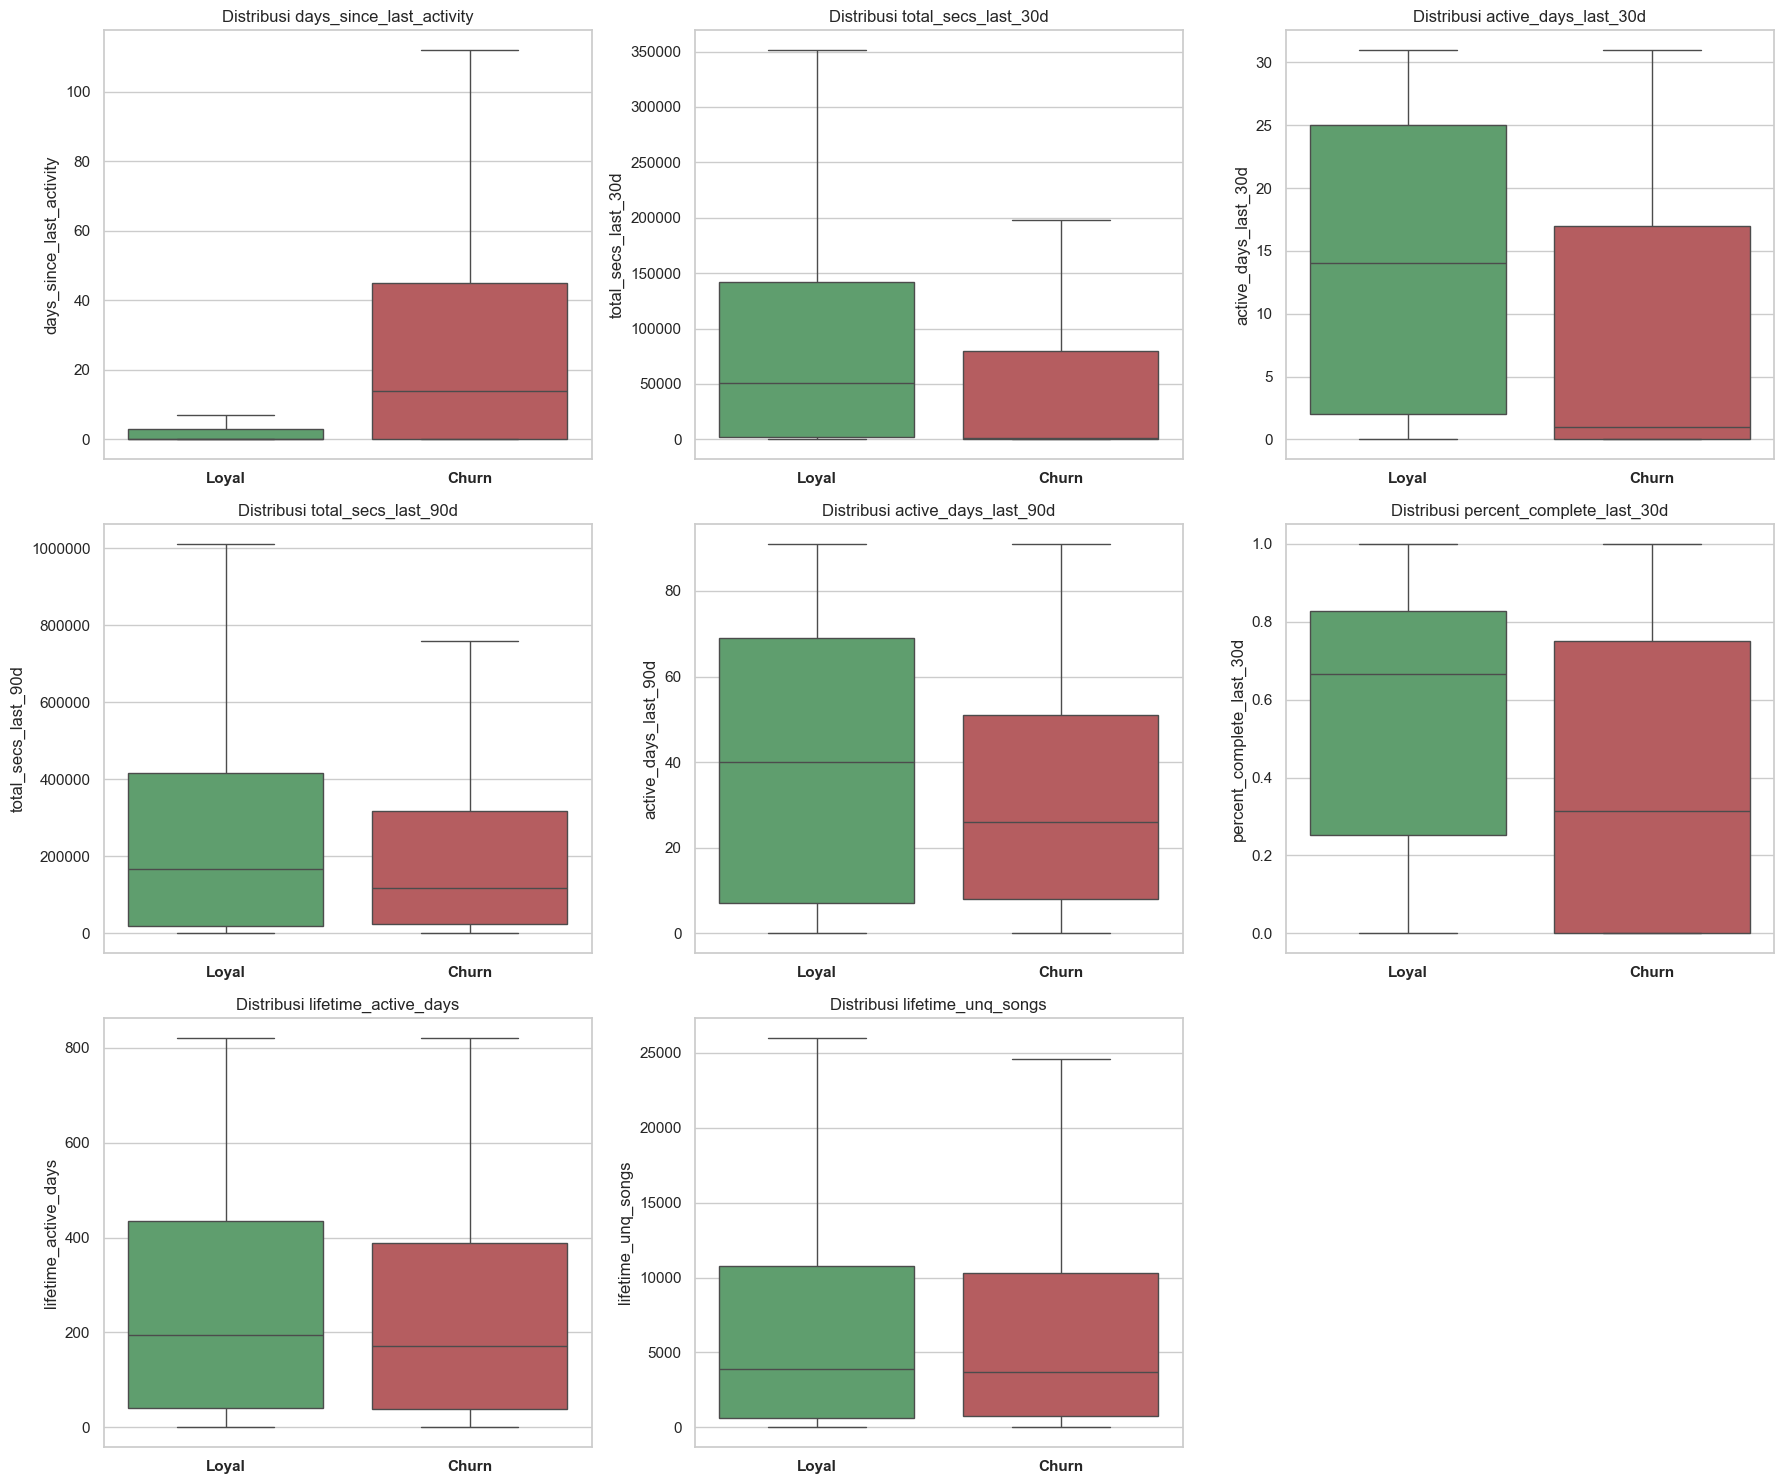

In [ ]:
# Daftar fitur logs
log_features = [
    'days_since_last_activity', 
    'active_days_last_30d', 
    'active_days_last_90d', 
    'percent_complete_last_30d', 
    'lifetime_active_days', 
    'lifetime_unq_songs'
]


# Churn = merah, Loyal = hijau
custom_colors = {
    0: "#55a868", 1: "#c44e52",     
    "0": "#55a868", "1": "#c44e52"  
}


# Setup Grid
n_cols = 3
n_rows = math.ceil(len(log_features) / n_cols)
plt.figure(figsize=(18, 5 * n_rows))

for i, feature in enumerate(log_features):
    plt.subplot(n_rows, n_cols, i + 1)
    
    sns.boxplot(
        data=master_table_pd, 
        x='is_churn', 
        y=feature, 
        hue='is_churn',         
        palette=custom_colors,  
        showfliers=False,   # Sembunyikan outliers
        legend=False            # Matikan legend bawaan
    )


    plt.ticklabel_format(style='plain', axis='y')
    plt.title(f'Distribusi {feature}', fontsize=12)
    plt.xlabel('') 
    plt.ylabel(feature)
    
    # Ganti angka 0/1 jadi teks Loyal/Churn
    plt.xticks(ticks=[0, 1], labels=['Loyal', 'Churn'], fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

In [ ]:
#spark
# Asumsi: DataFrame Spark kamu bernama 'df_spark'

log_features = [
    'days_since_last_activity', 
    'active_days_last_30d', 
    'active_days_last_90d', 
    'percent_complete_last_30d', 
    'lifetime_active_days', 
    'lifetime_unq_songs'
]

master_table_pd = df_spark.select(log_features + ['is_churn']).toPandas()

custom_colors = {
    0: "#55a868", 1: "#c44e52",     
    "0": "#55a868", "1": "#c44e52"  
}

# Setup Grid
n_cols = 3
n_rows = math.ceil(len(log_features) / n_cols)
plt.figure(figsize=(18, 5 * n_rows))

for i, feature in enumerate(log_features):
    plt.subplot(n_rows, n_cols, i + 1)
    
    sns.boxplot(
        data=master_table_pd, 
        x='is_churn', 
        y=feature, 
        hue='is_churn',         
        palette=custom_colors,  
        showfliers=False,   # Outlier disembunyikan
        legend=False        # Matikan legend bawaan
    )

    plt.ticklabel_format(style='plain', axis='y')
    plt.title(f'Distribusi {feature}', fontsize=12)
    plt.xlabel('') 
    plt.ylabel(feature)
    
    # Ganti angka 0/1 jadi teks Loyal/Churn
    plt.xticks(ticks=[0, 1], labels=['Loyal', 'Churn'], fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

## Jumlah Detik Putar Lagu (LOG SCALE)

In [ ]:

# Daftar fitur logs (ASLI DETIK)
log_features = ['total_secs_last_30d', 'total_secs_last_90d'] 

custom_colors = {0: "#55a868", 1: "#c44e52", "0": "#55a868", "1": "#c44e52"}

plt.figure(figsize=(12, 6))

for i, feature in enumerate(log_features):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(
        data=master_table_pd, 
        x='is_churn', 
        y=feature, 
        hue='is_churn',
        palette=custom_colors,
        showfliers=True,  
        legend=False
    )
    
    plt.yscale('log') 
    
    plt.title(f'{feature} (Log Scale)', fontsize=12, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Detik (Skala Log)')
    plt.xticks(ticks=[0, 1], labels=['Loyal', 'Churn'], fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

In [ ]:
#spark 

import matplotlib.pyplot as plt
import seaborn as sns
import math

cols_to_plot = ['total_secs_last_30d', 'total_secs_last_90d', 'is_churn']

master_table_pd_log = df_spark.select(cols_to_plot).toPandas()

log_features = ['total_secs_last_30d', 'total_secs_last_90d'] 

custom_colors = {
    0: "#55a868", 1: "#c44e52", 
    "0": "#55a868", "1": "#c44e52"
}

plt.figure(figsize=(12, 6))

for i, feature in enumerate(log_features):
    plt.subplot(1, 2, i + 1)
    
    sns.boxplot(
        data=master_table_pd_log,  
        x='is_churn', 
        y=feature, 
        hue='is_churn',
        palette=custom_colors,
        showfliers=True, 
        legend=False
    )
    
    plt.yscale('log') 
    
    plt.title(f'{feature} (Log Scale)', fontsize=12, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Detik (Skala Log)')
    plt.xticks(ticks=[0, 1], labels=['Loyal', 'Churn'], fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

# VALIDASI STATISTIK

--- Analisis Cramér's V (Hubungan Kategorikal dengan Churn) ---
                        Feature  P-Value Significant  Cramers_V  \
3  most_frequent_payment_method      0.0         Yes     0.4774   
2                registered_via      0.0         Yes     0.2380   
1                     age_group      0.0         Yes     0.1581   
0                          city      0.0         Yes     0.1174   

               Impact  
3  Medium (0.30-0.50)  
2   Small (0.10-0.30)  
1   Small (0.10-0.30)  
0   Small (0.10-0.30)  


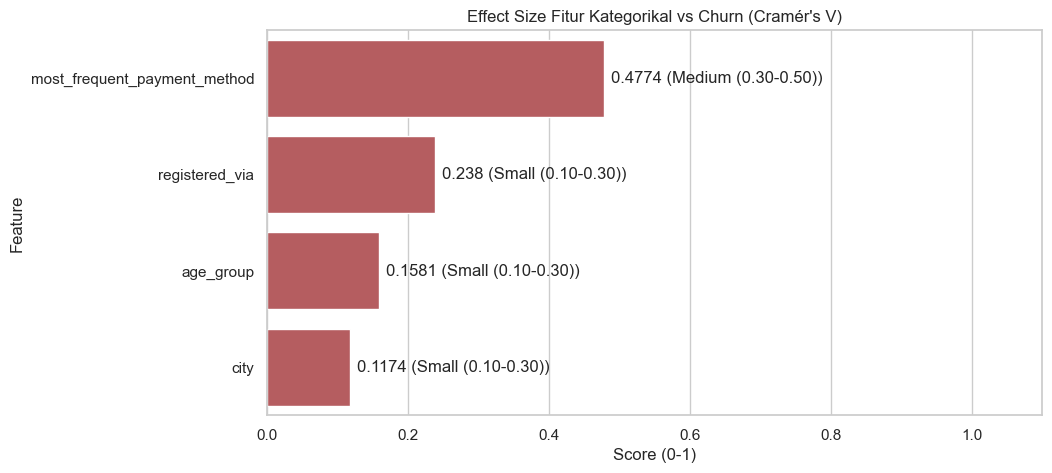

In [ ]:
# ==========================================
# CHISQ & CRAMER'S V (Untuk Kategorikal)
# ==========================================

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Fitur kategorikal 
cat_features = ['city', 'age_group', 'registered_via', 'most_frequent_payment_method']
target = 'is_churn'

print("--- Analisis Cramér's V (Hubungan Kategorikal dengan Churn) ---")

results = []
for feature in cat_features:
    # Pastikan tidak ada missing values saat perhitungan
    valid_data = master_table_pd[[feature, target]].dropna()

    # Hitung P-Value Chi-Square -> signifikansi
    crosstab = pd.crosstab(valid_data[feature], valid_data[target])
    chi2, p, dof, expected = stats.chi2_contingency(crosstab)
    
    # Hitung Cramér's V -> effect size
    score = cramers_v(valid_data[feature], valid_data[target])
    
    if score < 0.10:
        impact = "Negligible/ Dapat Diabaikan (<0.10)"
    elif score < 0.30:
        impact = "Small (0.10-0.30)"
    elif score < 0.50:
        impact = "Medium (0.30-0.50)"
    else:
        impact = "Large (>0.50)"
    results.append({
        'Feature': feature,
        'P-Value': round(p, 6),
        'Significant': 'Yes' if p < 0.05 else 'No',
        'Cramers_V': round(score, 4),
        'Impact': impact  
    })

# Buat DataFrame hasil
df_cramers = pd.DataFrame(results).sort_values(by='Cramers_V', ascending=False)
print(df_cramers)

# Visualisasi Cramér's V
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_cramers, x='Cramers_V', y='Feature', color='#c44e52')

# Menambahkan label teks Impact di ujung batang grafik
for i in range(len(df_cramers)):
    score = df_cramers.iloc[i]['Cramers_V']
    impact_text = df_cramers.iloc[i]['Impact']
    plt.text(score + 0.01, i, f"{score} ({impact_text})", va='center')

plt.title("Effect Size Fitur Kategorikal vs Churn (Cramér's V)")
plt.xlabel("Score (0-1)")
plt.xlim(0, 1.1)
plt.show()

In [ ]:
#spark

def cramers_v_calculation(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    if min((kcorr-1), (rcorr-1)) == 0:
        return 0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))


df_spark = spark.createDataFrame(master_table_pd) # Asumsi data kamu masih di Pandas variable

cat_features = ['city', 'age_group', 'registered_via', 'most_frequent_payment_method']
target = 'is_churn'

print("--- Analisis Cramér's V (Hubungan Kategorikal dengan Churn) ---")

results = []

for feature in cat_features:
    ct_spark = df_spark.na.drop(subset=[feature, target]).stat.crosstab(feature, target)
    ct_pd = ct_spark.toPandas()
    first_col = ct_pd.columns[0]
    ct_pd = ct_pd.set_index(first_col)
    
    # Hitung P-Value
    chi2, p, dof, expected = stats.chi2_contingency(ct_pd)
    
    # Hitung Cramér's V
    score = cramers_v_calculation(ct_pd)
    
    if score < 0.10:
        impact = "Negligible (<0.10)"
    elif score < 0.30:
        impact = "Small (0.10-0.30)"
    elif score < 0.50:
        impact = "Medium (0.30-0.50)"
    else:
        impact = "Large (>0.50)"

    results.append({
        'Feature': feature,
        'P-Value': float(p), # Pastikan float python biasa
        'Significant': 'Yes' if p < 0.05 else 'No',
        'Cramers_V': round(score, 4),
        'Impact': impact  
    })

df_cramers = pd.DataFrame(results).sort_values(by='Cramers_V', ascending=False)
print(df_cramers)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_cramers, x='Cramers_V', y='Feature', color='#c44e52')

for i in range(len(df_cramers)):
    score = df_cramers.iloc[i]['Cramers_V']
    impact_text = df_cramers.iloc[i]['Impact']
    plt.text(score + 0.01, i, f"{score} ({impact_text})", va='center')

plt.title("Effect Size Fitur Kategorikal vs Churn (Cramér's V)")
plt.xlabel("Score (0-1)")
plt.xlim(0, 1.2) 
plt.show()

In [ ]:
# ==========================================
# Mann-Whitney U Test & Rank-Biserial Correlation (Untuk Numerik)
# ==========================================

# Fitur numerik
num_features = [
    'total_transactions', 'total_plan_days', 'total_amount_paid', 
    'avg_amount_paid', 'count_auto_renew', 'count_cancel', 
    'days_since_last_activity', 'total_secs_last_30d', 
    'active_days_last_30d', 'percent_complete_last_30d',
    'total_secs_last_90d', 'active_days_last_90d',
    'lifetime_active_days', 'lifetime_unq_songs', 
]

results_effect = []

print("--- Analisis Rank-Biserial Correlation (Hubungan Numerik dengan Churn)---\n")

for feature in num_features:
    # Ambil data (Dropna agar akurat)
    group_churn = master_table_pd[master_table_pd['is_churn'] == 1][feature].dropna()
    group_not_churn = master_table_pd[master_table_pd['is_churn'] == 0][feature].dropna()
    
    n1 = len(group_churn)
    n2 = len(group_not_churn)
    
    # Hitung Mann-Whitney U
    # Kita butuh nilai 'stat' (U-statistic) untuk menghitung effect size
    stat, p_value = stats.mannwhitneyu(group_churn, group_not_churn, alternative='two-sided')
    
    # --- RUMUS EFFECT SIZE (Rank-Biserial) ---
    # r = 1 - (2 * U) / (n1 * n2)
    # n1 * n2 adalah total kemungkinan pasangan
    u_total = n1 * n2
    r = 1 - (2 * stat) / u_total
    
    abs_r = abs(r)
    impact = "Negligible/Dapat Diabaikan (<0.1)"
    if abs_r >= 0.5: impact = "Huge (>0.5)"
    elif abs_r >= 0.3: impact = "Medium (0.3-0.5)"
    elif abs_r >= 0.1: impact = "Small (0.1-0.3)"
    
    # Arah Hubungan (Positif/Negatif)
    # Jika r Positif: Median Churn > Median Tidak Churn
    # Jika r Negatif: Median Churn < Median Tidak Churn
    direction = "Churn Higher" if r > 0 else "Churn Lower"

    results_effect.append({
        'Feature': feature,
        'P-Value': p_value,
        'Effect Size (r)': round(r, 4),
        'Magnitude': impact,
        'Direction': direction
    })

df_effect = pd.DataFrame(results_effect)
# Bikin kolom absolut untuk sorting
df_effect['abs_r'] = df_effect['Effect Size (r)'].abs()
df_effect = df_effect.sort_values(by='abs_r', ascending=False).drop(columns=['abs_r'])

print(df_effect)

--- Analisis Rank-Biserial Correlation (Hubungan Numerik dengan Churn)---

                      Feature        P-Value  Effect Size (r)  \
4            count_auto_renew   0.000000e+00           0.6081   
0          total_transactions   0.000000e+00           0.5051   
3             avg_amount_paid   0.000000e+00          -0.4637   
6    days_since_last_activity   0.000000e+00          -0.3744   
8        active_days_last_30d   0.000000e+00           0.2975   
7         total_secs_last_30d   0.000000e+00           0.2788   
9   percent_complete_last_30d   0.000000e+00           0.2537   
1             total_plan_days   0.000000e+00           0.1762   
2           total_amount_paid   0.000000e+00           0.1709   
5                count_cancel   0.000000e+00          -0.1406   
11       active_days_last_90d   0.000000e+00           0.1355   
10        total_secs_last_90d  2.121627e-274           0.0679   
12       lifetime_active_days   3.930203e-53           0.0295   
13         life

In [ ]:
#spark, gatau bisa n hasilny sama atau nda soalnya di spark gada fungsi mannwhitneyu. Hitungny manual

import numpy as np
import pandas as pd
import scipy.stats as stats
from pyspark.sql import Window
import pyspark.sql.functions as F

df_spark = spark.createDataFrame(master_table_pd)

# Fitur numerik
num_features = [
    'total_transactions', 'total_plan_days', 'total_amount_paid', 
    'avg_amount_paid', 'count_auto_renew', 'count_cancel', 
    'days_since_last_activity', 'total_secs_last_30d', 
    'active_days_last_30d', 'percent_complete_last_30d',
    'total_secs_last_90d', 'active_days_last_90d',
    'lifetime_active_days', 'lifetime_unq_songs', 
]

results_effect = []

print("--- Analisis Rank-Biserial Correlation ---\n")

for feature in num_features:
    df_clean = df_spark.select(feature, 'is_churn').na.drop()
    
    # HITUNG RANKING (RANK SUM)
    # Mann-Whitney butuh ranking dari SELURUH data (gabungan churn & loyal)
    window_spec = Window.orderBy(F.col(feature))
    df_ranked = df_clean.withColumn("rank_val", F.rank().over(window_spec))
    
    # AGREGASI DATA (Hitung n dan Sum of Ranks per grup)
    agg_results = df_ranked.groupBy("is_churn").agg(
        F.count("*").alias("n"),
        F.sum("rank_val").alias("sum_rank")
    ).collect()
    
    
    row_churn = next((row for row in agg_results if row['is_churn'] == 1), None)
    row_loyal = next((row for row in agg_results if row['is_churn'] == 0), None)
    
    # Cek jika data lengkap
    if not row_churn or not row_loyal:
        print(f"Skipping {feature}: Data salah satu grup kosong.")
        continue
        
    n1 = row_churn['n']          # Jumlah user Churn
    n2 = row_loyal['n']          # Jumlah user Loyal
    R1 = row_churn['sum_rank']   # Total Rank user Churn
    
    # HITUNG MANN-WHITNEY U
    # Rumus U1 = R1 - (n1 * (n1 + 1)) / 2
    U1 = R1 - (n1 * (n1 + 1)) / 2
    
    # HITUNG RANK-BISERIAL CORRELATION (r)
    # Rumus: r = (2 * U1) / (n1 * n2) - 1
    u_total = n1 * n2
    r = (2 * U1) / u_total - 1
    
    # HITUNG P-VALUE (Z-Approximation)
    # Karena data besar, kita pakai pendekatan distribusi normal (Z-test)
    mu = u_total / 2
    sigma = np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12)
    z_score = (U1 - mu) / sigma
    
    # P-value (Two-sided)
    p_value = stats.norm.sf(abs(z_score)) * 2 
    
    abs_r = abs(r)
    impact = "Negligible/Dapat Diabaikan (<0.1)"
    if abs_r >= 0.5: impact = "Huge (>0.5)"
    elif abs_r >= 0.3: impact = "Medium (0.3-0.5)"
    elif abs_r >= 0.1: impact = "Small (0.1-0.3)"
    
    direction = "Churn Higher" if r > 0 else "Churn Lower"

    results_effect.append({
        'Feature': feature,
        'P-Value': float(p_value),
        'Effect Size (r)': round(r, 4),
        'Magnitude': impact,
        'Direction': direction
    })

# Tampilkan Hasil
df_effect = pd.DataFrame(results_effect)
df_effect['abs_r'] = df_effect['Effect Size (r)'].abs()
df_effect = df_effect.sort_values(by='abs_r', ascending=False).drop(columns=['abs_r'])

print(df_effect)

## Correlation

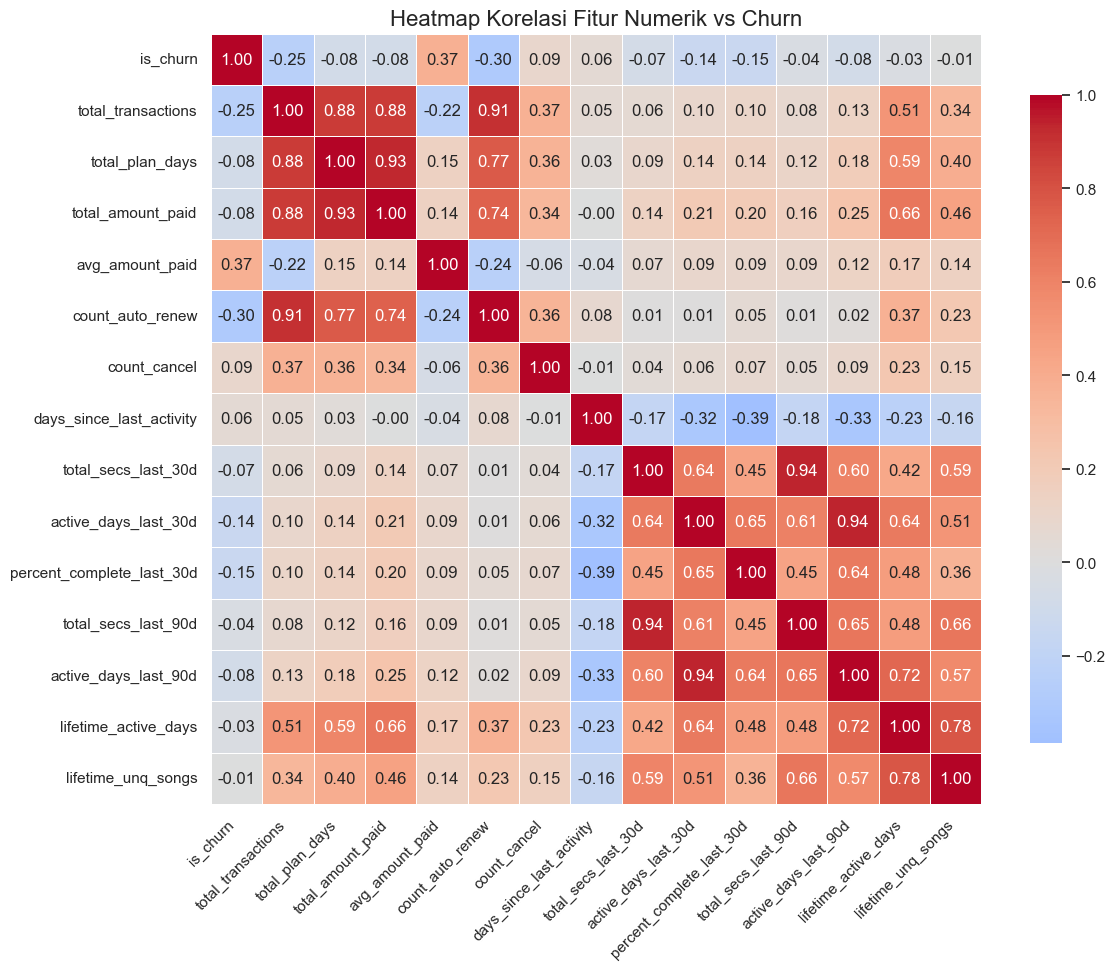

In [ ]:
df = master_table_pd 
numerical_cols = [
    'is_churn', 
    'total_transactions', 'total_plan_days', 'total_amount_paid', 
    'avg_amount_paid', 'count_auto_renew', 'count_cancel', 
    'days_since_last_activity', 'total_secs_last_30d', 
    'active_days_last_30d', 'percent_complete_last_30d',
    'total_secs_last_90d', 'active_days_last_90d',
    'lifetime_active_days', 'lifetime_unq_songs'
]

# Hitung matriks korelasi Pearson
corr_matrix = df[numerical_cols].corr(method='pearson')

# Visualisasi Heatmap
plt.figure(figsize=(12, 10)) # Ukuran disesuaikan

sns.heatmap(
    corr_matrix,
    annot=True,        # Tampilkan angka
    fmt=".2f",         # 2 angka di belakang koma
    cmap="coolwarm",   # Biru (Negatif) - Merah (Positif)
    center=0,          # Titik tengah warna di angka 0
    linewidths=.5,
    square=True,      
    cbar_kws={"shrink": .8}
)

plt.title('Heatmap Korelasi Fitur Numerik vs Churn', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
#spark
df_spark = spark.createDataFrame(master_table_pd)

numerical_cols = [
    'is_churn', 
    'total_transactions', 'total_plan_days', 'total_amount_paid', 
    'avg_amount_paid', 'count_auto_renew', 'count_cancel', 
    'days_since_last_activity', 'total_secs_last_30d', 
    'active_days_last_30d', 'percent_complete_last_30d',
    'total_secs_last_90d', 'active_days_last_90d',
    'lifetime_active_days', 'lifetime_unq_songs'
]

df_clean = df_spark.fillna(0, subset=numerical_cols)
print("Menyiapkan Vector Features...")
assembler = VectorAssembler(
    inputCols=numerical_cols,
    outputCol="corr_features"
)

# Transformasi data
df_vector = assembler.transform(df_clean).select("corr_features")

# Hitung korelasi pakai Pearson
corr_result = Correlation.corr(df_vector, "corr_features", "pearson").head()


corr_matrix_array = corr_result[0].toArray()

# Buat Pandas DataFrame agar bisa dibaca Seaborn
corr_matrix_pd = pd.DataFrame(
    corr_matrix_array, 
    columns=numerical_cols, 
    index=numerical_cols
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix_pd,
    annot=True,        # Tampilkan angka
    fmt=".2f",         # 2 angka di belakang koma
    cmap="coolwarm",   # Biru (Negatif) - Merah (Positif)
    center=0,          # Titik tengah warna di angka 0
    linewidths=.5,
    square=True,      
    cbar_kws={"shrink": .8}
)

plt.title('Heatmap Korelasi Fitur Numerik vs Churn (Spark Version)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()